# Phase 2 Extension — Preliminary Results
## Krauss et al. (2017) Multi-Objective Extension

Extension models trained on **same walk-forward structure** as Phase 1 (23 periods, 750/250 days).

**Models**: Multitask DNN (shared trunk + two heads), XGB (clf + reg), RF (clf + reg)

**Three score families** per model + ENS1:
- **P-only**: rank by P̂ = P(U > 0) — same as Phase 1 baseline
- **U-only**: rank by Û (predicted excess return)
- **Composite**: rank by (2P̂ − 1) · Û

**Key question**: Does aligning scoring with expected trading opportunity improve net returns?

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

sys.path.insert(0, str(Path('..') / 'src'))
from krauss.backtest.ranking import rank_and_select
from krauss.backtest.portfolio import build_daily_portfolios, aggregate_portfolio_returns
from krauss.backtest.costs import compute_turnover, apply_transaction_costs

ROOT = Path('..')
PROCESSED = ROOT / 'data' / 'processed'

# Load Phase 2 predictions and returns
pred2 = pd.read_parquet(PROCESSED / 'predictions_phase2.parquet')
pred1 = pd.read_parquet(PROCESSED / 'predictions_phase1.parquet')
returns = pd.read_parquet(PROCESSED / 'daily_returns.parquet')

pred2['date'] = pd.to_datetime(pred2['date'])
pred1['date'] = pd.to_datetime(pred1['date'])
returns['date'] = pd.to_datetime(returns['date'])

K_VALUES = [10, 50, 100, 150, 200]
COST_BPS = 5

print(f'Phase 2 predictions: {len(pred2):,} rows, {pred2["date"].nunique()} trade days, {pred2["period_id"].nunique()} periods')
print(f'Phase 1 predictions: {len(pred1):,} rows')
print(f'Returns: {len(returns):,} rows')

Phase 2 predictions: 2,852,210 rows, 5750 trade days, 23 periods
Phase 1 predictions: 2,852,210 rows
Returns: 5,764,478 rows


In [3]:
def run_backtest(predictions, score_col, k, returns_df, cost_bps=5):
    """Run full backtest pipeline for a score column and k."""
    sel = rank_and_select(predictions, k=k, score_col=score_col)
    hold = build_daily_portfolios(sel, returns_df, k=k)
    daily = aggregate_portfolio_returns(hold)
    turn = compute_turnover(hold, k=k)
    daily = apply_transaction_costs(daily, turn, cost_bps)
    daily['date'] = pd.to_datetime(daily['date'])
    return daily

# --- Phase 1 baseline backtests (P-only from original classifiers) ---
bt_p1 = {}
for model_col in ['p_rf', 'p_xgb', 'p_dnn', 'p_ens1']:
    for k in K_VALUES:
        bt_p1[(model_col, k)] = run_backtest(pred1, model_col, k, returns)
        r = bt_p1[(model_col, k)]['port_ret'].mean()
        print(f'  P1 {model_col} k={k}: {r:.4f}/day')
print('Phase 1 baselines done.\n')

# --- Phase 2 backtests: all score families ---
# Score columns: score_p_*, score_u_*, score_comp_* for dnn, xgb, rf, ens1
bt_p2 = {}
for family in ['dnn', 'xgb', 'rf', 'ens1']:
    for score_type, score_col in [('P', f'score_p_{family}'),
                                   ('U', f'score_u_{family}'),
                                   ('Comp', f'score_comp_{family}')]:
        for k in K_VALUES:
            key = (family, score_type, k)
            bt_p2[key] = run_backtest(pred2, score_col, k, returns)
            r = bt_p2[key]['port_ret'].mean()
            print(f'  P2 {family}/{score_type} k={k}: {r:.4f}/day')
print('\nPhase 2 backtests done.')

  P1 p_rf k=10: 0.0041/day
  P1 p_rf k=50: 0.0023/day
  P1 p_rf k=100: 0.0016/day
  P1 p_rf k=150: 0.0012/day
  P1 p_rf k=200: 0.0010/day
  P1 p_xgb k=10: 0.0035/day
  P1 p_xgb k=50: 0.0021/day
  P1 p_xgb k=100: 0.0014/day
  P1 p_xgb k=150: 0.0011/day
  P1 p_xgb k=200: 0.0008/day
  P1 p_dnn k=10: 0.0021/day
  P1 p_dnn k=50: 0.0012/day
  P1 p_dnn k=100: 0.0008/day
  P1 p_dnn k=150: 0.0006/day
  P1 p_dnn k=200: 0.0004/day
  P1 p_ens1 k=10: 0.0041/day
  P1 p_ens1 k=50: 0.0022/day
  P1 p_ens1 k=100: 0.0015/day
  P1 p_ens1 k=150: 0.0012/day
  P1 p_ens1 k=200: 0.0009/day
Phase 1 baselines done.

  P2 dnn/P k=10: 0.0022/day
  P2 dnn/P k=50: 0.0012/day
  P2 dnn/P k=100: 0.0008/day
  P2 dnn/P k=150: 0.0006/day
  P2 dnn/P k=200: 0.0004/day
  P2 dnn/U k=10: 0.0014/day
  P2 dnn/U k=50: 0.0008/day
  P2 dnn/U k=100: 0.0005/day
  P2 dnn/U k=150: 0.0004/day
  P2 dnn/U k=200: 0.0003/day
  P2 dnn/Comp k=10: 0.0016/day
  P2 dnn/Comp k=50: 0.0009/day
  P2 dnn/Comp k=100: 0.0006/day
  P2 dnn/Comp k=150: 0.

## Headline Comparison: Phase 1 vs Phase 2 Score Families (k=10)

Daily mean return (pre- and post-cost) for each model × score family at k=10.

In [13]:
def safe_ratio(num, denom, default=0.0):
    return num / denom if pd.notna(denom) and denom > 0 else default

def daily_stats(daily_df, ret_col='port_ret'):
    """Compute summary stats from a daily return series."""
    r = daily_df[ret_col]
    ann_ret = r.mean() * 252
    ann_std = r.std() * np.sqrt(252)
    downside = r[r < 0].std() * np.sqrt(252)
    sharpe = safe_ratio(ann_ret - 0.02, ann_std)
    sortino = safe_ratio(ann_ret - 0.02, downside)
    dd = (r.cumsum() - r.cumsum().cummax()).min()
    return {
        'Daily Mean': r.mean(),
        'Ann. Return': ann_ret,
        'Ann. Std': ann_std,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Max DD': dd,
        'Hit Rate': (r > 0).mean(),
    }

# Build comparison table for k=10
rows = []
model_map = {'p_rf': 'RF', 'p_xgb': 'XGB', 'p_dnn': 'DNN', 'p_ens1': 'ENS1'}

for model_col, m_name in model_map.items():
    family = model_col.replace('p_', '')
    
    # Phase 1 baseline
    d = bt_p1[(model_col, 10)]
    s_pre = daily_stats(d, 'port_ret')
    s_post = daily_stats(d, 'port_ret_net')
    rows.append({
        'Model': m_name, 'Score': 'P1 Baseline',
        'Pre-cost ret/day': s_pre['Daily Mean'],
        'Post-cost ret/day': s_post['Daily Mean'],
        'Sharpe (post)': s_post['Sharpe'],
        'Sortino (post)': s_post['Sortino'],
        'Max DD (post)': s_post['Max DD'],
        'Hit Rate (post)': s_post['Hit Rate'],
        'Ann. Turnover': d['turnover'].mean() * 252,
    })
    
    # Phase 2 extension score families (U and Composite only)
    for score_type in ['U', 'Comp']:
        d2 = bt_p2[(family, score_type, 10)]
        s_pre = daily_stats(d2, 'port_ret')
        s_post = daily_stats(d2, 'port_ret_net')
        rows.append({
            'Model': m_name, 'Score': f'P2 {score_type}',
            'Pre-cost ret/day': s_pre['Daily Mean'],
            'Post-cost ret/day': s_post['Daily Mean'],
            'Sharpe (post)': s_post['Sharpe'],
            'Sortino (post)': s_post['Sortino'],
            'Max DD (post)': s_post['Max DD'],
            'Hit Rate (post)': s_post['Hit Rate'],
            'Ann. Turnover': d2['turnover'].mean() * 252,
        })

headline = pd.DataFrame(rows).set_index(['Model', 'Score'])
headline_fmt = headline.style.format({
    'Pre-cost ret/day': '{:.4f}',
    'Post-cost ret/day': '{:.4f}',
    'Sharpe (post)': '{:.2f}',
    'Sortino (post)': '{:.2f}',
    'Max DD (post)': '{:.2%}',
    'Hit Rate (post)': '{:.1%}',
    'Ann. Turnover': '{:.1f}',
}).set_caption('Phase 1 vs Phase 2 — k=10 daily return characteristics')
display(headline_fmt)

## k-Sensitivity: P1 Baseline vs P2 Score Families (ENS1)

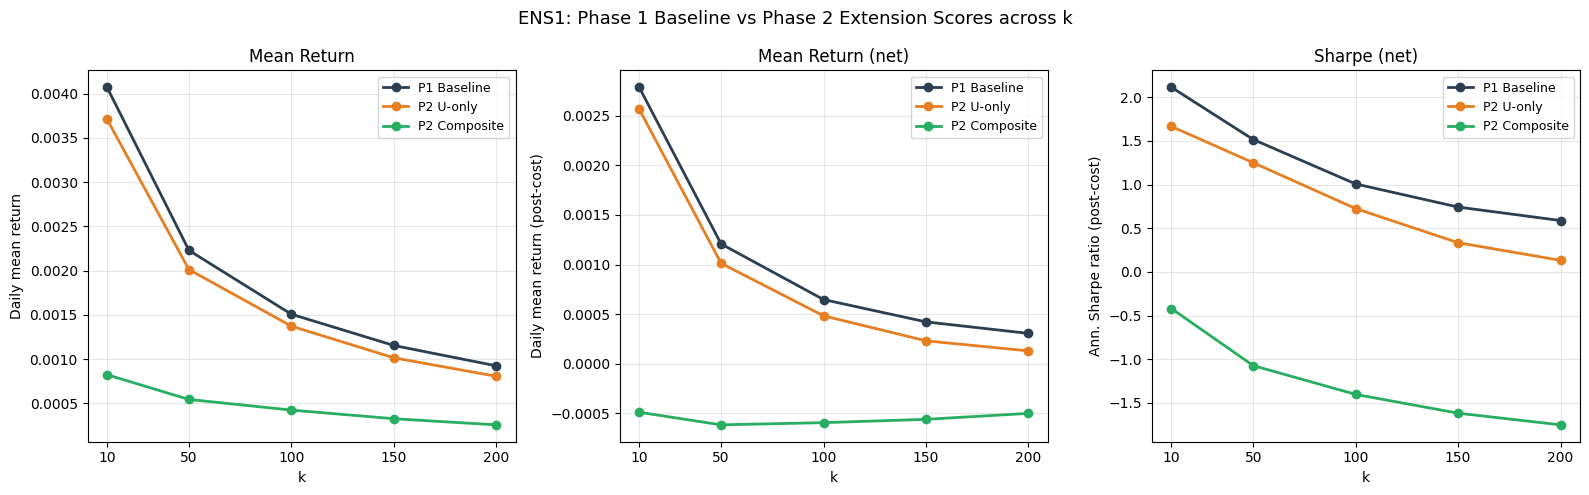

In [14]:
# k-sensitivity comparison: ENS1 across score families
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'P1 Baseline': '#2c3e50', 'P2 U-only': '#e67e22', 'P2 Composite': '#27ae60'}

for ax, (metric, ylabel, ret_col) in zip(axes, [
    ('Mean Return', 'Daily mean return', 'port_ret'),
    ('Mean Return (net)', 'Daily mean return (post-cost)', 'port_ret_net'),
    ('Sharpe (net)', 'Ann. Sharpe ratio (post-cost)', None),
]):
    for label, color in colors.items():
        vals = []
        for k in K_VALUES:
            if label == 'P1 Baseline':
                d = bt_p1[('p_ens1', k)]
            else:
                score_map = {'P2 U-only': 'U', 'P2 Composite': 'Comp'}
                d = bt_p2[('ens1', score_map[label], k)]
            
            if metric == 'Sharpe (net)':
                s = daily_stats(d, 'port_ret_net')
                vals.append(s['Sharpe'])
            else:
                vals.append(d[ret_col].mean())
        
        ax.plot(K_VALUES, vals, 'o-', label=label, color=color, linewidth=2, markersize=6)
    
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel)
    ax.set_title(metric)
    ax.legend(fontsize=9)
    ax.set_xticks(K_VALUES)
    ax.grid(alpha=0.3)

fig.suptitle('ENS1: Phase 1 Baseline vs Phase 2 Extension Scores across k', fontsize=13)
plt.tight_layout()
plt.show()

## Equity Curves: P1 ENS1 vs P2 Score Families (k=10, post-cost)

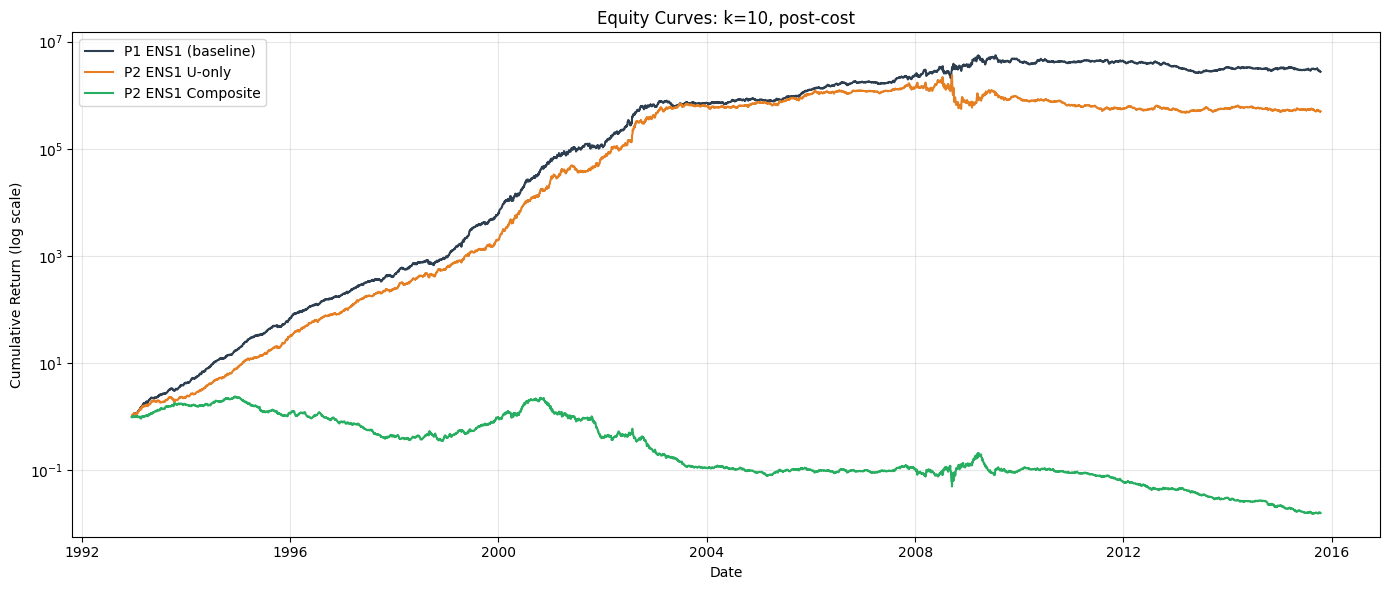

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

# P1 ENS1 baseline
d1 = bt_p1[('p_ens1', 10)].sort_values('date')
eq1 = (1 + d1['port_ret_net']).cumprod()
ax.plot(d1['date'], eq1, label='P1 ENS1 (baseline)', color='#2c3e50', linewidth=1.5)

# P2 extension score families (U and Composite only)
for score_type, label, color in [
    ('U', 'P2 ENS1 U-only', '#e67e22'),
    ('Comp', 'P2 ENS1 Composite', '#27ae60'),
]:
    d2 = bt_p2[('ens1', score_type, 10)].sort_values('date')
    eq2 = (1 + d2['port_ret_net']).cumprod()
    ax.plot(d2['date'], eq2, label=label, color=color, linewidth=1.5)

ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log scale)')
ax.set_xlabel('Date')
ax.set_title('Equity Curves: k=10, post-cost')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sub-Period Analysis (k=10, post-cost)

In [16]:
sub_periods = [
    ('12/92-03/01', '1992-12-01', '2001-03-31'),
    ('04/01-08/08', '2001-04-01', '2008-08-31'),
    ('09/08-12/09', '2008-09-01', '2009-12-31'),
    ('01/10-10/15', '2010-01-01', '2015-10-31'),
]

rows = []
strategies = [
    ('P1 Baseline', lambda: bt_p1[('p_ens1', 10)]),
    ('P2 U-only',   lambda: bt_p2[('ens1', 'U', 10)]),
    ('P2 Composite', lambda: bt_p2[('ens1', 'Comp', 10)]),
]

for strat_name, get_df in strategies:
    d = get_df()
    for sp_label, start, end in sub_periods:
        sub = d[(d['date'] >= start) & (d['date'] <= end)]
        if len(sub) == 0:
            continue
        r = sub['port_ret_net']
        ann_ret = r.mean() * 252
        ann_std = r.std() * np.sqrt(252)
        sharpe = safe_ratio(ann_ret - 0.02, ann_std)
        dd = (r.cumsum() - r.cumsum().cummax()).min()
        rows.append({
            'Strategy': strat_name,
            'Period': sp_label,
            'Ann. Return': ann_ret,
            'Sharpe': sharpe,
            'Max DD': dd,
            'N days': len(sub),
        })

sub_df = pd.DataFrame(rows)
sub_pivot = sub_df.pivot_table(
    index='Strategy', columns='Period',
    values=['Ann. Return', 'Sharpe'],
).round(4)

# Reorder columns by period
period_order = [sp[0] for sp in sub_periods]
sub_pivot = sub_pivot.reindex(columns=period_order, level=1)

display(sub_pivot.style.format('{:.4f}').set_caption('ENS1 sub-period analysis (k=10, post-cost)'))

## Per-Model Breakdown: All 3 Base Models × Score Families (k=10)

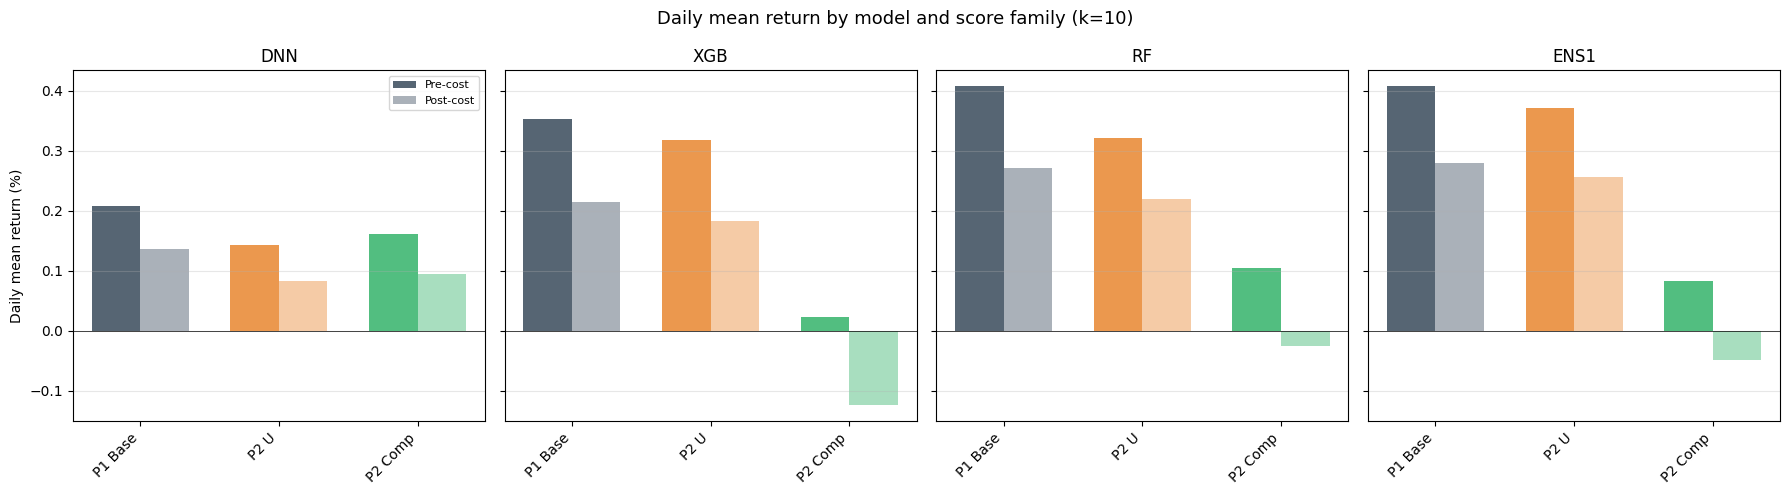

In [17]:
# Compact per-model comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

model_families = [('DNN', 'dnn', 'p_dnn'), ('XGB', 'xgb', 'p_xgb'),
                  ('RF', 'rf', 'p_rf'), ('ENS1', 'ens1', 'p_ens1')]
bar_colors = ['#2c3e50', '#e67e22', '#27ae60']
score_labels = ['P1 Base', 'P2 U', 'P2 Comp']

for ax, (m_name, family, p1_col) in zip(axes, model_families):
    pre = []
    post = []
    
    # P1 baseline
    d = bt_p1[(p1_col, 10)]
    pre.append(d['port_ret'].mean() * 100)
    post.append(d['port_ret_net'].mean() * 100)
    
    # P2 extension scores (U and Composite only)
    for st in ['U', 'Comp']:
        d2 = bt_p2[(family, st, 10)]
        pre.append(d2['port_ret'].mean() * 100)
        post.append(d2['port_ret_net'].mean() * 100)
    
    x = np.arange(len(score_labels))
    width = 0.35
    ax.bar(x - width/2, pre, width, label='Pre-cost', color=bar_colors, alpha=0.8)
    ax.bar(x + width/2, post, width, label='Post-cost', color=bar_colors, alpha=0.4)
    
    ax.set_title(m_name)
    ax.set_xticks(x)
    ax.set_xticklabels(score_labels, rotation=45, ha='right')
    if ax == axes[0]:
        ax.set_ylabel('Daily mean return (%)')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.grid(axis='y', alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle('Daily mean return by model and score family (k=10)', fontsize=13)
plt.tight_layout()
plt.show()

## Turnover Comparison

Key diagnostic: does the composite score reduce turnover (by preferring to hold stocks with large expected excess returns)?

In [18]:
turnover_rows = []
for m_name, family, p1_col in model_families:
    # P1
    d = bt_p1[(p1_col, 10)]
    turnover_rows.append({
        'Model': m_name, 'Score': 'P1 Baseline',
        'Mean daily turnover': d['turnover'].mean(),
        'Mean daily cost': d['cost'].mean(),
    })
    for st in ['U', 'Comp']:
        d2 = bt_p2[(family, st, 10)]
        turnover_rows.append({
            'Model': m_name, 'Score': f'P2 {st}',
            'Mean daily turnover': d2['turnover'].mean(),
            'Mean daily cost': d2['cost'].mean(),
        })

turn_df = pd.DataFrame(turnover_rows).set_index(['Model', 'Score'])
display(turn_df.style.format({
    'Mean daily turnover': '{:.4f}',
    'Mean daily cost': '{:.6f}',
}).set_caption('Turnover and cost comparison (k=10)'))

## Long/Short Leg Decomposition (k=10, post-cost)

In [19]:
strategies = [
    ('P1 Baseline', lambda: bt_p1[('p_ens1', 10)]),
    ('P2 U-only',   lambda: bt_p2[('ens1', 'U', 10)]),
    ('P2 Composite', lambda: bt_p2[('ens1', 'Comp', 10)]),
]

leg_rows = []
for strat_name, get_df in strategies:
    d = get_df()
    leg_rows.append({
        'Strategy': strat_name,
        'Long leg (daily)': d['long_ret'].mean(),
        'Short leg (daily)': d['short_ret'].mean(),
        'L-S spread (daily)': d['port_ret'].mean(),
        'Long ann.': d['long_ret'].mean() * 252,
        'Short ann.': d['short_ret'].mean() * 252,
    })

leg_df = pd.DataFrame(leg_rows).set_index('Strategy')
display(leg_df.style.format('{:.4f}').set_caption('Long/short leg decomposition — ENS1, k=10'))

,Long leg (daily),Short leg (daily),L-S spread (daily),Long ann.,Short ann.
Strategy,,,,,
P1 Baseline,0.0026,-0.0015,0.0041,0.6461,-0.3800
P2 U-only,0.0026,-0.0011,0.0037,0.6476,-0.2876
P2 Composite,0.0013,0.0005,0.0008,0.3392,0.1314


## Prediction Quality: P̂ and Û Diagnostics

In [20]:
# Merge predictions with realized labels to check prediction quality
labels = pd.read_parquet(PROCESSED / 'labels.parquet')
labels['date'] = pd.to_datetime(labels['date'])

merged = pred2.merge(
    labels[['date', 'permno', 'u_excess', 'y_binary']],
    on=['date', 'permno'], how='inner'
)

print(f'Merged rows: {len(merged):,}')
print()

# P-hat calibration: does P_hat correlate with realized binary outcome?
from sklearn.metrics import roc_auc_score

print('AUC for P(U > 0) predictions on trade data:')
for col, name in [('p_dnn', 'MT-DNN'), ('p_xgb', 'XGB'), ('p_rf', 'RF'), ('p_ens1', 'ENS1')]:
    auc = roc_auc_score(merged['y_binary'], merged[col])
    print(f'  {name}: {auc:.4f}')

# Compare with Phase 1 P-hat AUC
merged1 = pred1.merge(
    labels[['date', 'permno', 'y_binary']],
    on=['date', 'permno'], how='inner'
)
print('\nAUC for Phase 1 P-hat (baseline classifiers):')
for col, name in [('p_dnn', 'DNN'), ('p_xgb', 'XGB'), ('p_rf', 'RF'), ('p_ens1', 'ENS1')]:
    auc = roc_auc_score(merged1['y_binary'], merged1[col])
    print(f'  {name}: {auc:.4f}')

# U-hat quality: correlation with realized U
print('\nCorrelation of U_hat with realized U_excess:')
for col, name in [('u_dnn', 'MT-DNN'), ('u_xgb', 'XGB'), ('u_rf', 'RF'), ('u_ens1', 'ENS1')]:
    corr = merged[col].corr(merged['u_excess'])
    print(f'  {name}: {corr:.4f}')

Merged rows: 2,852,210

AUC for P(U > 0) predictions on trade data:
  MT-DNN: 0.5126
  XGB: 0.5183
  RF: 0.5188
  ENS1: 0.5190

AUC for Phase 1 P-hat (baseline classifiers):
  DNN: 0.5138
  XGB: 0.5183
  RF: 0.5188
  ENS1: 0.5190

Correlation of U_hat with realized U_excess:
  MT-DNN: -0.0006
  XGB: 0.0272
  RF: 0.0080
  ENS1: 0.0149


## Summary Table: All Models × Score Families × k Values (post-cost Sharpe)

In [21]:
# Full Sharpe heatmap: model × score × k
sharpe_rows = []
for m_name, family, p1_col in model_families:
    for k in K_VALUES:
        # P1
        d = bt_p1[(p1_col, k)]
        s = daily_stats(d, 'port_ret_net')
        sharpe_rows.append({'Model': m_name, 'Score': 'P1 Base', 'k': k, 'Sharpe': s['Sharpe']})
        # P2 extension scores (U and Composite only)
        for st in ['U', 'Comp']:
            d2 = bt_p2[(family, st, k)]
            s2 = daily_stats(d2, 'port_ret_net')
            sharpe_rows.append({'Model': m_name, 'Score': f'P2 {st}', 'k': k, 'Sharpe': s2['Sharpe']})

sharpe_df = pd.DataFrame(sharpe_rows)
sharpe_pivot = sharpe_df.pivot_table(index=['Model', 'Score'], columns='k', values='Sharpe')
sharpe_pivot = sharpe_pivot[K_VALUES]

# Color: green = good, red = bad
display(sharpe_pivot.style.format('{:.2f}').background_gradient(
    cmap='RdYlGn', axis=None
).set_caption('Post-cost annualized Sharpe ratio by model, score family, and k'))